# Tracking Timestamp Investigation

## 2023-24 Tracking Data

Season parquet:

`processed/tracking/20232024.parquet`

### Overall seconds_to_goal range

```text
min: -12.0
max:  11.9
```

### Example Goal

For the first goal inspected:

```text
frame_idx    seconds_to_goal
0            -11.9
1            -11.8
2            -11.7
...
118          -0.1
119           0.0
```

This event contains approximately 12 seconds of tracking leading
up to the goal and no post-goal tracking.

### Other Events

Some events contain substantial tracking after the official goal time:

```text
game_id       event_id    min    max
2023020134    991        -0.1   11.8
2023020989    350        -1.4   10.5
2023020751    377        -2.5    9.4
```

### Initial Observation

The tracking window is not positioned consistently relative to
`seconds_to_goal = 0`.

Some clips contain mostly pre-goal tracking, while others contain
substantial post-goal tracking.

In [ ]:
# Lets look at a particular gameid

from pathlib import Path
import pandas as pd

parquet_path = Path("../processed/tracking/20232024.parquet")

df = pd.read_parquet(
    parquet_path,
    columns=[
        "game_id",
        "event_id",
        "frame_idx",
        "seconds_to_goal",
        "entity_type",
        "player_id",
        "team_id",
        "sweater_number",
        "is_goalie",
        "is_scorer",
        "x",
        "y",
        "home_team_id",
        "away_team_id"
    ],
    filters=[("game_id", "==", 2023020001)]
)

In [ ]:
# Look at the columns and types
print(df.dtypes.to_string())

game_id              int64
event_id             int64
frame_idx            int32
seconds_to_goal    float32
entity_type         object
player_id          float64
team_id            float64
sweater_number     float64
is_goalie           object
is_scorer           object
x                  float32
y                  float32
home_team_id         int32
away_team_id         int32


In [ ]:
# Lets look at some eventids

df[["game_id", "event_id"]].drop_duplicates().head(20)

,game_id,event_id
0,2023020001,154
1581,2023020001,165
3229,2023020001,740
4789,2023020001,170
6229,2023020001,171
7850,2023020001,830
9298,2023020001,176
10751,2023020001,179


In [5]:
event_id = 154   # choose event 154

clip = df[df["event_id"] == event_id]

clip[
    ["player_id", "sweater_number", "team_id", "is_goalie", "is_scorer"]
].drop_duplicates().sort_values("team_id")

,player_id,sweater_number,team_id,is_goalie,is_scorer
1,8474564.0,91.0,14.0,False,False
3,8480246.0,48.0,14.0,False,False
5,8475167.0,77.0,14.0,False,False
4,8478010.0,21.0,14.0,False,False
11,8476453.0,86.0,14.0,False,True
1537,8479542.0,38.0,14.0,False,False
9,8477992.0,31.0,14.0,True,False
2,8478468.0,3.0,18.0,False,False
7,8481704.0,75.0,18.0,False,False
6,8476887.0,9.0,18.0,False,False


In [ ]:
player_id = 8476453 # lets examine the scorers coordinates

player_track = clip[
    clip["player_id"] == player_id
][
    ["frame_idx", "seconds_to_goal", "x", "y"]
].sort_values("frame_idx")

player_track

,frame_idx,seconds_to_goal,x,y
11,0,-11.9,-29.410000,-26.111000
25,1,-11.8,-29.643999,-24.379000
39,2,-11.7,-29.591999,-22.618000
53,3,-11.6,-29.291000,-20.872999
67,4,-11.5,-28.775000,-19.170000
...,...,...,...,...
1522,115,-0.4,40.724998,-18.857000
1535,116,-0.3,40.599998,-18.844999
1550,117,-0.2,40.493999,-18.872000
1564,118,-0.1,40.414001,-18.920000


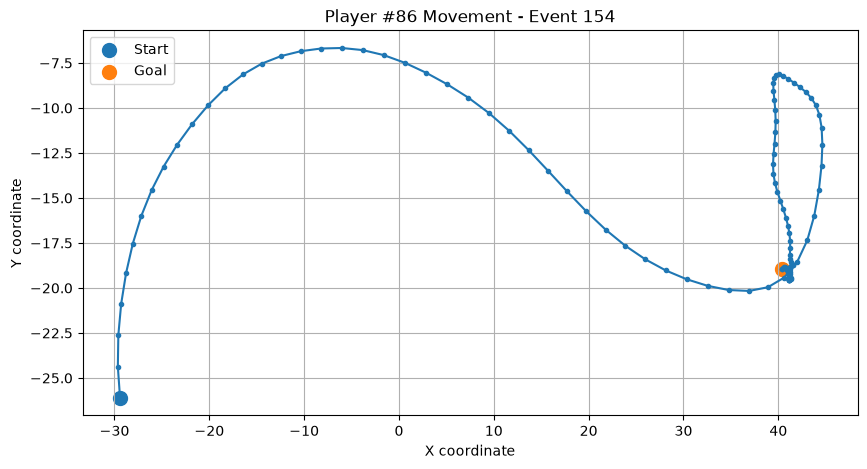

In [ ]:
# Lets plot his positions

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    player_track["x"],
    player_track["y"],
    marker="o",
    markersize=3
)

plt.scatter(
    player_track.iloc[0]["x"],
    player_track.iloc[0]["y"],
    s=100,
    label="Start"
)

plt.scatter(
    player_track.iloc[-1]["x"],
    player_track.iloc[-1]["y"],
    s=100,
    label="Goal"
)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Player #86 Movement - Event 154")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# Lets see the processed files

from pathlib import Path

list(Path("../processed").iterdir())

[WindowsPath('../processed/clip_availability.parquet'),
 WindowsPath('../processed/edge_goalies'),
 WindowsPath('../processed/edge_skaters'),
 WindowsPath('../processed/events'),
 WindowsPath('../processed/faceoffs'),
 WindowsPath('../processed/games'),
 WindowsPath('../processed/players.parquet'),
 WindowsPath('../processed/shifts'),
 WindowsPath('../processed/shots'),
 WindowsPath('../processed/tracking'),
 WindowsPath('../processed/web_clips')]

In [ ]:
# Lets look at Players file

players = pd.read_parquet("../processed/players.parquet")

print(players.columns.tolist())
players.head()

['playerId', 'firstName', 'lastName', 'positionCode']


,playerId,firstName,lastName,positionCode
0,8470594,Marc-Andre,Fleury,G
1,8470600,Ryan,Suter,D
2,8470604,Jeff,Carter,C
3,8470610,Zach,Parise,L
4,8470613,Brent,Burns,D


In [ ]:
player_id = 8476453 # Find our scorer

players[
    players["playerId"] == player_id
]

,playerId,firstName,lastName,positionCode
200,8476453,Nikita,Kucherov,R


In [ ]:
# Used NHL_Explorer to watch the clip .. numbers make sense

games = pd.read_parquet("../processed/games")

games[
    games["game_id"] == 2023020001
]

,season,game_id,game_date,game_type,home_team_id,home_team_abbrev,away_team_id,away_team_abbrev
0,20232024,2023020001,2023-10-10,2,14,TBL,18,NSH


In [ ]:
# Looks like centre ice is (0,0)

df[["x", "y"]].agg(["min", "max"])

,x,y
min,-98.700996,-42.088001
max,99.901001,42.754002


Lets check the normalization


In [ ]:
import pyarrow.parquet as pq #use pyarrow to read parquet file schema info (no data loading)

pf = pq.ParquetFile("../processed/tracking/20232024.parquet")

print("\n".join(pf.schema_arrow.names))

season
game_id
event_id
period
time_in_period
abs_game_seconds
situation_code
shot_type
home_team_id
away_team_id
scoring_team_id
conceding_team_id
pbp_scorer_id
net_x
net_source
flip
goal_frame_idx
shot_frame_idx
frame_idx
time_stamp
seconds_to_goal
seconds_to_shot
is_goal_frame
is_shot_frame
n_onice
entity_id
entity_type
player_id
team_id
team_abbrev
sweater_number
position_code
is_goalie
is_scorer
is_assist1
is_assist2
is_scoring_team
is_home
x
y
x_att
y_att
dist_to_net_ft
angle_to_net_deg
dist_to_puck_ft


In [14]:
# compare x,y, x_att, y_att

df_coords = pd.read_parquet(
    "../processed/tracking/20232024.parquet",
    columns=[
        "game_id",
        "event_id",
        "frame_idx",
        "player_id",
        "seconds_to_goal",
        "x",
        "y",
        "x_att",
        "y_att"
    ],
    filters=[("game_id", "==", 2023020001)]
)

df_coords[
    (df_coords["event_id"] == 154) &
    (df_coords["player_id"] == 8476453)
][
    ["frame_idx", "seconds_to_goal", "x", "y", "x_att", "y_att"]
].tail(10)

,frame_idx,seconds_to_goal,x,y,x_att,y_att
1457,110,-0.9,41.115002,-19.312000,41.115002,-19.312000
1470,111,-0.8,41.084000,-19.216000,41.084000,-19.216000
1483,112,-0.7,41.029999,-19.107000,41.029999,-19.107000
1496,113,-0.6,40.953999,-19.000000,40.953999,-19.000000
1509,114,-0.5,40.848999,-18.912001,40.848999,-18.912001
1522,115,-0.4,40.724998,-18.857000,40.724998,-18.857000
1535,116,-0.3,40.599998,-18.844999,40.599998,-18.844999
1550,117,-0.2,40.493999,-18.872000,40.493999,-18.872000
1564,118,-0.1,40.414001,-18.920000,40.414001,-18.920000
1578,119,0.0,40.363998,-18.968000,40.363998,-18.968000


In [ ]:
# See if x,y can differ from x_att, y_att

different = df_coords[
    (df_coords["x"] != df_coords["x_att"]) |
    (df_coords["y"] != df_coords["y_att"])
]

different[
    [
        "game_id",
        "event_id",
        "frame_idx",
        "player_id",
        "x",
        "y",
        "x_att",
        "y_att"
    ]
].head(20)

,game_id,event_id,frame_idx,player_id,x,y,x_att,y_att
3229,2023020001,740,0,8474151.0,26.187000,-12.788000,-26.187000,12.788000
3230,2023020001,740,0,8474564.0,-12.842000,-4.148000,12.842000,4.148000
3231,2023020001,740,0,8480246.0,-33.141998,-8.235000,33.141998,8.235000
3232,2023020001,740,0,8478010.0,1.960000,15.197000,-1.960000,-15.197000
3233,2023020001,740,0,8475167.0,-23.865000,29.392000,23.865000,-29.392000
3234,2023020001,740,0,8476887.0,3.348000,-18.461000,-3.348000,18.461000
3235,2023020001,740,0,8481704.0,-13.864000,16.424000,13.864000,-16.424000
3236,2023020001,740,0,8477424.0,88.249001,0.458000,-88.249001,-0.458000
3237,2023020001,740,0,8478851.0,14.750000,18.111000,-14.750000,-18.111000
3238,2023020001,740,0,8477992.0,-88.532997,0.048000,88.532997,-0.048000


Raw coordinates:
x, y
→ can attack either direction

Normalized coordinates:
x_att, y_att
→ rotated when necessary so attacks are aligned consistently